In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

tips = pd.read_csv('https://frenzy86.s3.eu-west-2.amazonaws.com/fav/tips.csv')
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [2]:
tips["Male"]=tips["sex"].copy
tips["Female"]=tips["sex"].copy
tips["Dinner"]=tips["time"].copy
tips["Lunch"]=tips["time"].copy
tips['Male'] = tips['Male'].apply(lambda x: 1 if x == 'Male' else 0)
tips['Female'] = tips['Female'].apply(lambda x: 1 if x == 'Female' else 0)
tips['smoker'] = tips['smoker'].apply(lambda x: 1 if x == 'yes' else 0)
tips['Dinner'] = tips['Dinner'].apply(lambda x: 1 if x == 'Dinner' else 0)
tips['Lunch'] = tips['Lunch'].apply(lambda x: 1 if x == 'Lunch' else 0)

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X = tips[['total_bill','Male','Female','smoker','Dinner','Lunch','size']]
y = tips['tip']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
B0=model.intercept_
B1,B2,B3,B4,B5,B6,B7=model.coef_
print(B0,B1,B2,B3,B4,B5,B6,B7)

0.5681370921350046 0.09088116781495426 0.0 0.0 0.0 0.0 0.0 0.2650175437880634


In [5]:
tips.to_excel('Restaurant.xlsx', index=False)

In [8]:
y_pred=model.predict(X_test)

In [11]:
pd.DataFrame(list(zip(y_pred,y_test)),columns=['predicted','true'])

,predicted,true
0,2.899437,3.18
1,1.895200,2.00
2,3.859340,2.00
3,3.981121,5.16
4,2.279627,2.00
5,2.724036,2.00
6,3.682833,2.56
7,2.232369,2.52
8,2.441396,3.23
9,2.495925,3.00


In [18]:
np.linspace(0,10,100)

array([ 0.        ,  0.1010101 ,  0.2020202 ,  0.3030303 ,  0.4040404 ,
        0.50505051,  0.60606061,  0.70707071,  0.80808081,  0.90909091,
        1.01010101,  1.11111111,  1.21212121,  1.31313131,  1.41414141,
        1.51515152,  1.61616162,  1.71717172,  1.81818182,  1.91919192,
        2.02020202,  2.12121212,  2.22222222,  2.32323232,  2.42424242,
        2.52525253,  2.62626263,  2.72727273,  2.82828283,  2.92929293,
        3.03030303,  3.13131313,  3.23232323,  3.33333333,  3.43434343,
        3.53535354,  3.63636364,  3.73737374,  3.83838384,  3.93939394,
        4.04040404,  4.14141414,  4.24242424,  4.34343434,  4.44444444,
        4.54545455,  4.64646465,  4.74747475,  4.84848485,  4.94949495,
        5.05050505,  5.15151515,  5.25252525,  5.35353535,  5.45454545,
        5.55555556,  5.65656566,  5.75757576,  5.85858586,  5.95959596,
        6.06060606,  6.16161616,  6.26262626,  6.36363636,  6.46464646,
        6.56565657,  6.66666667,  6.76767677,  6.86868687,  6.96

In [12]:
length = len(y_test) #y_pred.shape[0]
x=np.linspace(0,length,length)

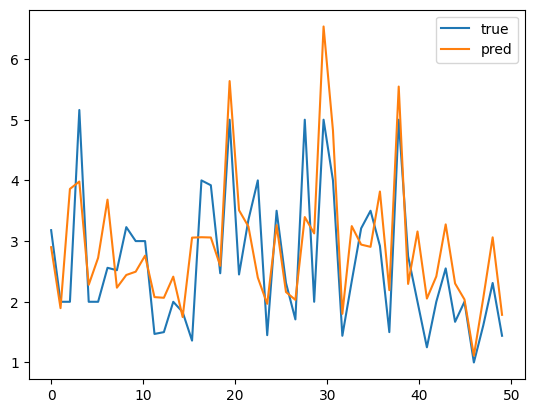

In [16]:
plt.plot(x,y_test,label="true")
plt.plot(x,y_pred,label="pred")
plt.legend()

In [20]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(x=x, y=y_test, name="real", mode="lines"))
fig.add_trace(go.Scatter(x=x, y=y_pred, name="predicted", mode="lines"))
fig.update_layout(title="Error from prediction on Test Set", xaxis_title="Obeservation", yaxis_title="Value",width=900)
fig.show()